# 1. Modelo predictivo - Producto Nuevo (alto riesgo)

**Objetivo.** Construir un modelo de calificacion de clientes que permita seleccionar a aquellos con menor probabilidad de incumplimiento, definir la variable objetivo (Mora30 o Mora60) con justificacion tecnica y fijar un punto de corte alineado con riesgo y negocio.

**Roadmap del notebook:**
1. Carga, exploracion y limpieza
2. EDA: tasa de mala, comportamiento temporal, perfil de cliente
3. **Deteccion de data leakage** (hallazgo critico)
4. Seleccion de variable objetivo (Mora30 vs Mora60)
5. Feature engineering
6. Particionamiento temporal (out-of-time) + train/test
7. Modelado: Regresion Logistica (interpretable) + LightGBM (benchmark)
8. Punto de corte: analisis costo/beneficio
9. Conclusiones y recomendacion ejecutiva


## 0. Setup

In [1]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import lightgbm as lgb

import utils  # funciones de credit scoring (KS, Gini, PSI, IV, decile_table)

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

FIGS = "figuras"
os.makedirs(FIGS, exist_ok=True)
RANDOM_STATE = 42


## 1. Carga y limpieza inicial

In [2]:
# Notar: el archivo viene con encoding mojibake en categoricas (T�RMINO en vez de TERMINO).
# Lo arreglamos al cargar para que las tablas y graficos sean legibles.

REPLACE_MAP = {
    "T\ufffdRMINO INDEFINIDO": "TERMINO INDEFINIDO",
    "T\ufffdRMINO FIJO": "TERMINO FIJO",
    "TECN\ufffdLOGO": "TECNOLOGO",
}

df = pd.read_excel("../ProductoNuevo.xlsx")
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].replace(REPLACE_MAP, regex=False)
    df[col] = df[col].str.replace("\ufffd", "", regex=False)
print("Shape:", df.shape)
df.head(3)


Shape: (4315, 22)


,ID,FFECHA,Mora30,Mora60,MoraMax_UltimoSemestre,ExperienciaSectorFinanciero,PersonasCargo,GastosFamiliares,GastoArriendo,TiempoActividadAnios,OCUPACION,TIPCONTRATO,Edad,Estado_Civil,Genero,Ingresos,Nivel_Academico,Tipo_Vivienda,TiempoClienteMeses,Tiempo_SistemaFro,PORCEND,Obligaciones_SistemaFro
0,1,201710,0,0,0,0,0,7837.87,0,10,JUBILADOS/PENSIONADO,TÉRMINO INDEFINIDO,61,CASADO,MASCULINO,11698.313433,TECNÓLOGO,PROPIA,40,0,1.020685,0
1,2,201711,1,0,59,0,1,9194.07,0,1,EMPLEADO,TÉRMINO INDEFINIDO,45,CASADO,FEMENINO,13722.492537,TECNÓLOGO,ALQUILADA,0,0,0.543829,0
2,3,201704,0,0,30,1,1,8450.00,0,1,EMPLEADO,TÉRMINO FIJO,55,CASADO,MASCULINO,12611.940299,BACHILLER,PROPIA,13,73,0.946746,0


In [3]:
# Tipado coherente y limpieza de outliers obvios
# - TiempoActividadAnios > 100 es claramente erroneo (probable error de digitacion en meses/dias).
# - GastoArriendo en escala muy alta (max 300k) cuando los ingresos rondan 9k-15k: tambien sospechoso.
# Optamos por winsorizar (cap) en percentiles altos en lugar de eliminar registros, conservando volumen.

print("Outliers TiempoActividadAnios > 100:", (df["TiempoActividadAnios"] > 100).sum())
print("Outliers GastoArriendo > 50000   :", (df["GastoArriendo"] > 50000).sum())

p99_act  = df["TiempoActividadAnios"].quantile(0.99)
p99_arr  = df["GastoArriendo"].quantile(0.99)
df["TiempoActividadAnios"] = df["TiempoActividadAnios"].clip(upper=p99_act)
df["GastoArriendo"]        = df["GastoArriendo"].clip(upper=p99_arr)

# fecha estudio como periodo
df["periodo"] = pd.to_datetime(df["FFECHA"].astype(str), format="%Y%m")
print("Periodo:", df["periodo"].min().strftime("%Y-%m"), "->", df["periodo"].max().strftime("%Y-%m"))
df[["TiempoActividadAnios","GastoArriendo"]].describe().T


Outliers TiempoActividadAnios > 100: 1
Outliers GastoArriendo > 50000   : 194
Periodo: 2017-01 -> 2018-09


,count,mean,std,min,25%,50%,75%,max
TiempoActividadAnios,4315.0,2.699421,3.361304,0.0,1.0,1.0,3.0,20.0
GastoArriendo,4315.0,6819.700348,32357.478344,0.0,0.0,0.0,0.0,200000.0


In [4]:
# Nulos y consistencia
print("Nulos por columna:")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicados ID:", df["ID"].duplicated().sum())


Nulos por columna:
ID                         0
Edad                       0
Obligaciones_SistemaFro    0
PORCEND                    0
Tiempo_SistemaFro          0
TiempoClienteMeses         0
Tipo_Vivienda              0
Nivel_Academico            0
Ingresos                   0
Genero                     0
dtype: int64

Duplicados ID: 0


## 2. EDA - perfil de la cartera y variable objetivo

Antes de modelar entendamos: tasa de mala global, su evolucion temporal y las dos definiciones de target.

                      Mora30    Mora60
Tasa malos            0.2436    0.1168
Cantidad de malos  1051.0000  504.0000


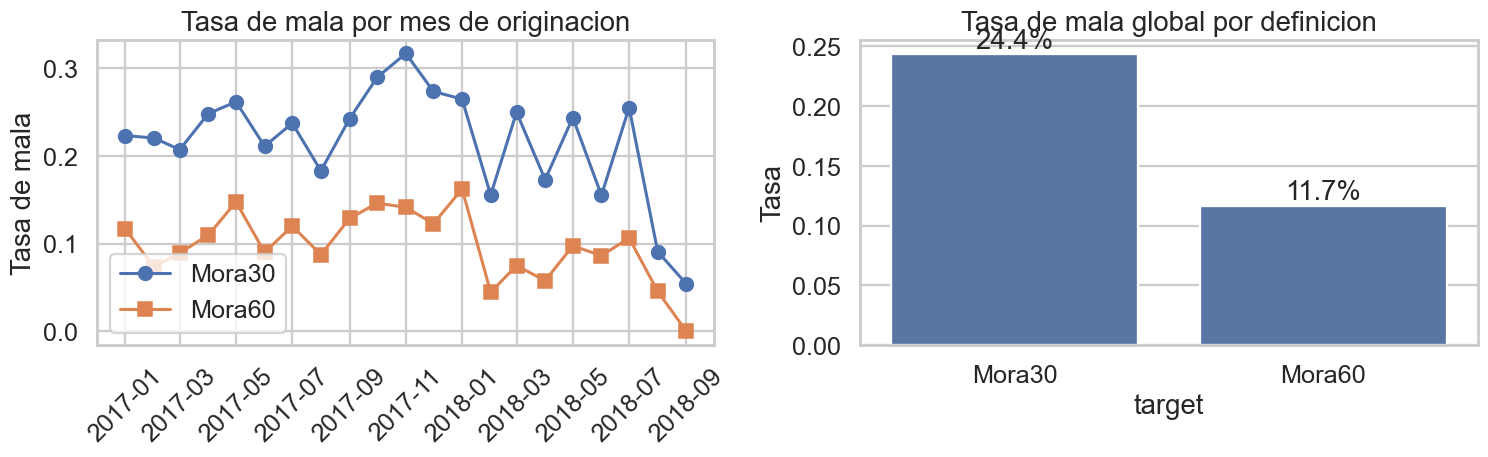

In [5]:
# Tasa de mala por definicion + evolucion mensual
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

target_summary = pd.DataFrame({
    "Mora30": [df["Mora30"].mean(), df["Mora30"].sum()],
    "Mora60": [df["Mora60"].mean(), df["Mora60"].sum()],
}, index=["Tasa malos", "Cantidad de malos"])
print(target_summary.round(4))

# Evolucion temporal de tasa de mala
ev = df.groupby("periodo")[["Mora30","Mora60"]].mean().reset_index()
axes[0].plot(ev["periodo"], ev["Mora30"], marker="o", label="Mora30", lw=2)
axes[0].plot(ev["periodo"], ev["Mora60"], marker="s", label="Mora60", lw=2)
axes[0].set_title("Tasa de mala por mes de originacion")
axes[0].set_ylabel("Tasa de mala")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# Distribucion de la variable MoraMax_UltimoSemestre por target
df_long = df.melt(value_vars=["Mora30","Mora60"], var_name="target", value_name="malo")
sns.barplot(data=df_long, x="target", y="malo", ax=axes[1], errorbar=None)
axes[1].set_title("Tasa de mala global por definicion")
axes[1].set_ylabel("Tasa")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.1f%%", labels=[f"{v.get_height()*100:.1f}%" for v in c])

plt.tight_layout()
plt.savefig(f"{FIGS}/01_target_overview.png", bbox_inches="tight")
plt.show()


In [6]:
# Volumen mensual: el ultimo trimestre (jul-sep 2018) tiene comportamiento estable
# y servira como hold-out *out-of-time* (OOT), buena practica de la industria.
volumen = df.groupby("periodo").size().rename("clientes").to_frame()
volumen["%mora30"] = df.groupby("periodo")["Mora30"].mean()
volumen["%mora60"] = df.groupby("periodo")["Mora60"].mean()
print(volumen.tail(12).round(3))


            clientes  %mora30  %mora60
periodo                               
2017-10-01       383    0.290    0.146
2017-11-01       410    0.317    0.141
2017-12-01       391    0.274    0.123
2018-01-01       117    0.265    0.162
2018-02-01        45    0.156    0.044
2018-03-01        40    0.250    0.075
2018-04-01        52    0.173    0.058
2018-05-01        41    0.244    0.098
2018-06-01        58    0.155    0.086
2018-07-01        47    0.255    0.106
2018-08-01        22    0.091    0.045
2018-09-01        37    0.054    0.000


## 3. [CRITICO] Deteccion de data leakage

**Hallazgo importante.** La variable `MoraMax_UltimoSemestre` resulto ser una variable contaminada con el target. La cruzamos contra las dos definiciones de mora:

In [7]:
# Cross-tab Mora60 vs (MoraMax >= 60) y Mora30 vs (MoraMax >= 30)
print("Cross-tab Mora60 vs (MoraMax_UltimoSemestre >= 60):")
print(pd.crosstab(df["Mora60"], df["MoraMax_UltimoSemestre"]>=60, margins=True))
print("\nCross-tab Mora30 vs (MoraMax_UltimoSemestre >= 30):")
print(pd.crosstab(df["Mora30"], df["MoraMax_UltimoSemestre"]>=30, margins=True))
print("\nCorrelacion Mora60 vs MoraMax:", round(df["Mora60"].corr(df["MoraMax_UltimoSemestre"]),3))
print("Correlacion Mora30 vs MoraMax:", round(df["Mora30"].corr(df["MoraMax_UltimoSemestre"]),3))


Cross-tab Mora60 vs (MoraMax_UltimoSemestre >= 60):
MoraMax_UltimoSemestre  False  True   All
Mora60                                   
0                        3767    44  3811
1                           0   504   504
All                      3767   548  4315

Cross-tab Mora30 vs (MoraMax_UltimoSemestre >= 30):
MoraMax_UltimoSemestre  False  True   All
Mora30                                   
0                        3028   236  3264
1                           0  1051  1051
All                      3028  1287  4315

Correlacion Mora60 vs MoraMax: 0.796
Correlacion Mora30 vs MoraMax: 0.759


**Lectura.** El 100% de los clientes con `Mora60=1` tiene `MoraMax_UltimoSemestre >= 60`, y el 100% de los `Mora30=1` tiene `MoraMax >= 30`. Esto significa que la variable es practicamente la *contencion logica del target* (probable que `MoraXX` haya sido construida como `(MoraMax >= XX)`).

**Decision.** Se **excluye `MoraMax_UltimoSemestre` del set de predictoras**. De lo contrario el modelo tendria KS ~ 1.0 - artificialmente perfecto y no extrapolable a producción.

**Por que esto importa.** En credit scoring, no detectar leakage es la falla mas costosa: el modelo se ve excelente en validacion y luego en produccion no discrimina porque la variable culpable no estaba disponible al momento del scoring. Detectarlo y documentarlo es parte de la calidad del trabajo de un Data Scientist.


In [8]:
# Excluimos la variable contaminada del set predictor
LEAKAGE_VARS = ["MoraMax_UltimoSemestre"]
print(f"Variables eliminadas por leakage: {LEAKAGE_VARS}")


Variables eliminadas por leakage: ['MoraMax_UltimoSemestre']


## 4. Seleccion de variable objetivo

**Comparativa Mora30 vs Mora60:**

| Criterio | Mora30 (24.4%) | Mora60 (11.7%) |
|---|---|---|
| Severidad | Cliente puede regularizarse rapido (1 mes) | Indicador mas claro de **deterioro real** |
| Prevalencia | Alta -> facil entrenar | Menor -> requiere tecnicas para clase minoritaria |
| Costo de error | Falsos negativos baratos (mora corta) | Falsos negativos costosos (mora dura, write-off) |
| Alineacion con apetito | Demasiado sensible para alto riesgo | Coherente con definicion **Basel-like** de default |
| Estabilidad | Influida por estacionalidad y comportamiento de pago | Mas robusta como senal de incumplimiento |

**Decision:** se elige **Mora60** como variable objetivo. Justificacion:

1. El producto se dirige a un **segmento de alto riesgo**, donde una mora de 30 dias es *frecuente y recuperable*. Tomar Mora30 sobreestimaria el numero de "malos" reales.
2. Mora60 esta mucho mas alineada con la definicion de **default operativo** que usa el equipo de cobranza/provisiones (deterioro cierto en cartera).
3. El costo del error en Mora60 (no detectar un default real) es **materialmente mayor** que el costo de aprobar un cliente que tendra una mora de 30 dias y se autocorregira.
4. Para mitigar la menor prevalencia (~12%) se trabajara con `class_weight="balanced"` y se reportaran metricas robustas a desbalance (KS, AUC) en lugar de exactitud.

Validamos cuantitativamente esta decision contrastando IV de las variables contra ambos targets (la senal predictiva debe sostenerse).

In [9]:
# Comparativa rapida de IV agregado entre los dos targets (excluyendo leakage)
predictoras = [c for c in df.columns
               if c not in ["ID","FFECHA","periodo","Mora30","Mora60"] + LEAKAGE_VARS]

iv30 = utils.iv_summary(df, "Mora30", predictoras).rename(columns={"IV":"IV_M30","fuerza":"fuerza_M30"})
iv60 = utils.iv_summary(df, "Mora60", predictoras).rename(columns={"IV":"IV_M60","fuerza":"fuerza_M60"})
iv_cmp = iv30.merge(iv60, on="variable").sort_values("IV_M60", ascending=False)
print("Top 10 variables por IV (Mora60):")
iv_cmp.head(10)


Top 10 variables por IV (Mora60):


,variable,IV_M30,fuerza_M30,IV_M60,fuerza_M60
0,Tiempo_SistemaFro,0.092680,debil,0.108545,media
2,TiempoClienteMeses,0.070731,debil,0.106882,media
1,PORCEND,0.089834,debil,0.093174,debil
4,Genero,0.057585,debil,0.078264,debil
3,Nivel_Academico,0.065495,debil,0.071205,debil
7,Estado_Civil,0.037560,debil,0.053564,debil
5,Ingresos,0.041801,debil,0.049783,debil
6,GastosFamiliares,0.038877,debil,0.038179,debil
8,TIPCONTRATO,0.027099,debil,0.025496,debil
12,TiempoActividadAnios,0.010115,no predictiva,0.024839,debil


In [10]:
# IV agregado: la senal global se mantiene similar entre Mora30 y Mora60.
# Esto nos da confianza para modelar Mora60 sin perder poder predictivo significativo.
print(f"IV total Mora30: {iv_cmp['IV_M30'].sum():.3f}")
print(f"IV total Mora60: {iv_cmp['IV_M60'].sum():.3f}")

TARGET = "Mora60"
print(f"\n>>> Variable objetivo seleccionada: {TARGET}")
print(f"    Tasa de mala: {df[TARGET].mean():.2%}  |  Malos: {df[TARGET].sum():,}  |  Buenos: {(1-df[TARGET]).sum():,.0f}")


IV total Mora30: 0.598
IV total Mora60: 0.698

>>> Variable objetivo seleccionada: Mora60
    Tasa de mala: 11.68%  |  Malos: 504  |  Buenos: 3,811


## 5. Feature engineering

Variables derivadas que tipicamente capturan riesgo en credit scoring:
- `arriendo_pct_ingreso`: carga de arriendo sobre ingresos
- `gasto_pct_ingreso`: gastos familiares sobre ingresos
- `flag_vivienda_propia`, `flag_genero_M`, etc. (binarizaciones simples)
- Aggregaciones sencillas de comportamiento financiero

No sobreingeniaremos: pocas variables bien construidas baten a muchas variables ruidosas.

In [11]:
data = df.copy()

# Razones financieras
data["arriendo_pct_ingreso"] = data["GastoArriendo"] / data["Ingresos"].replace(0, np.nan)
data["gasto_pct_ingreso"]    = data["GastosFamiliares"] / data["Ingresos"].replace(0, np.nan)
data["arriendo_pct_ingreso"] = data["arriendo_pct_ingreso"].fillna(0).clip(upper=2)
data["gasto_pct_ingreso"]    = data["gasto_pct_ingreso"].fillna(0).clip(upper=2)

# Bin para edad (no lineal en riesgo)
data["edad_grupo"] = pd.cut(data["Edad"],
                            bins=[0,25,35,45,55,100],
                            labels=["18-25","26-35","36-45","46-55","56+"]).astype(str)

# Definir matriz X / y
DROP = ["ID","FFECHA","periodo","Mora30","Mora60"] + LEAKAGE_VARS
X = data.drop(columns=DROP)
y = data[TARGET]

print("Predictoras:", X.shape[1])
print("Categoricas :", X.select_dtypes(include='object').columns.tolist())


Predictoras: 20
Categoricas : ['OCUPACION', 'TIPCONTRATO', 'Estado_Civil', 'Genero', 'Nivel_Academico', 'Tipo_Vivienda', 'edad_grupo']


## 6. Particionamiento out-of-time (OOT)

Separamos los **3 ultimos meses** como muestra OOT (validacion realista, simula despliegue) y el resto se reparte en train/test 80/20 estratificado.

In [12]:
# OOT: ultimo trimestre del periodo
corte_oot = data["periodo"].max() - pd.DateOffset(months=2)
mask_oot = data["periodo"] >= corte_oot
print(f"Corte OOT: {corte_oot.strftime('%Y-%m')}  |  registros OOT: {mask_oot.sum()}")

X_dev,  y_dev  = X[~mask_oot], y[~mask_oot]
X_oot,  y_oot  = X[ mask_oot], y[ mask_oot]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_dev, y_dev, test_size=0.20, random_state=RANDOM_STATE, stratify=y_dev
)

for name, yy in [("train", y_tr), ("test", y_te), ("OOT", y_oot)]:
    print(f"  {name:5s}  n={len(yy):5d}  tasa_mala={yy.mean():.2%}")


Corte OOT: 2018-07  |  registros OOT: 106
  train  n= 3367  tasa_mala=11.82%
  test   n=  842  tasa_mala=11.88%
  OOT    n=  106  tasa_mala=5.66%


## 7. Modelado

Construimos dos modelos:
- **Regresion logistica** con preprocesamiento (escalado num + dummies cat). Es el estandar en credit scoring por su interpretabilidad y porque permite construir una *scorecard* directa.
- **LightGBM** como benchmark (captura no linealidades e interacciones). Si la diferencia en KS/Gini es marginal, preferimos la logistica por interpretabilidad y trazabilidad regulatoria.

In [13]:
num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_tr.select_dtypes(include="object").columns.tolist()

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", "passthrough", cat_cols),
])
# usamos pd.get_dummies aparte para mantener nombres legibles en la logistica
def encode_frame(df_):
    return pd.get_dummies(df_, columns=cat_cols, drop_first=True)

X_tr_enc, X_te_enc, X_oot_enc = encode_frame(X_tr), encode_frame(X_te), encode_frame(X_oot)

# sanitizar nombres de columnas (LightGBM no acepta espacios ni caracteres especiales)
import re
def sanitize(c):
    return re.sub(r"[^0-9A-Za-z_]+", "_", str(c)).strip("_")
X_tr_enc.columns  = [sanitize(c) for c in X_tr_enc.columns]
X_te_enc.columns  = [sanitize(c) for c in X_te_enc.columns]
X_oot_enc.columns = [sanitize(c) for c in X_oot_enc.columns]

# alinear columnas (test/OOT pueden tener categorias ausentes)
X_te_enc  = X_te_enc.reindex(columns=X_tr_enc.columns, fill_value=0)
X_oot_enc = X_oot_enc.reindex(columns=X_tr_enc.columns, fill_value=0)

scaler = StandardScaler().fit(X_tr_enc)
X_tr_s  = scaler.transform(X_tr_enc)
X_te_s  = scaler.transform(X_te_enc)
X_oot_s = scaler.transform(X_oot_enc)


In [14]:
# 6.1 Logistica (con balanceo de clases)
logreg = LogisticRegression(
    penalty="l2", C=0.5, solver="liblinear",
    class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE,
)
logreg.fit(X_tr_s, y_tr)

p_tr_lr  = logreg.predict_proba(X_tr_s)[:,1]
p_te_lr  = logreg.predict_proba(X_te_s)[:,1]
p_oot_lr = logreg.predict_proba(X_oot_s)[:,1]

print("Logistica:")
print("  TRAIN", utils.model_metrics(y_tr,  p_tr_lr))
print("  TEST ", utils.model_metrics(y_te,  p_te_lr))
print("  OOT  ", utils.model_metrics(y_oot, p_oot_lr))


Logistica:
  TRAIN {'AUC': 0.666193463105355, 'Gini': 0.33238692621071, 'KS': 0.2544052360150365, 'n': 3367, 'tasa_mala': 0.1182061182061182}
  TEST  {'AUC': 0.5628436657681941, 'Gini': 0.12568733153638822, 'KS': 0.17237196765498652, 'n': 842, 'tasa_mala': 0.1187648456057007}
  OOT   {'AUC': 0.665, 'Gini': 0.33000000000000007, 'KS': 0.39, 'n': 106, 'tasa_mala': 0.05660377358490566}


In [15]:
# 6.2 LightGBM (benchmark)
# Con solo 3.4k registros y 397 malos, hay riesgo alto de overfit. Regularizamos
# fuerte: pocas hojas, min_child_samples alto, learning rate bajo y reg L1/L2.
gbm = lgb.LGBMClassifier(
    n_estimators=400, learning_rate=0.02, num_leaves=15,
    min_child_samples=80, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=1.0, max_depth=4,
    class_weight="balanced", random_state=RANDOM_STATE, verbose=-1
)
gbm.fit(X_tr_enc, y_tr, eval_set=[(X_te_enc, y_te)], callbacks=[lgb.early_stopping(40, verbose=False)])

p_tr_gbm  = gbm.predict_proba(X_tr_enc)[:,1]
p_te_gbm  = gbm.predict_proba(X_te_enc)[:,1]
p_oot_gbm = gbm.predict_proba(X_oot_enc)[:,1]

print("LightGBM:")
print("  TRAIN", utils.model_metrics(y_tr,  p_tr_gbm))
print("  TEST ", utils.model_metrics(y_te,  p_te_gbm))
print("  OOT  ", utils.model_metrics(y_oot, p_oot_gbm))


LightGBM:


  TRAIN {'AUC': 0.8229502175749073, 'Gini': 0.6459004351498145, 'KS': 0.495711971782117, 'n': 3367, 'tasa_mala': 0.1182061182061182}
  TEST  {'AUC': 0.5782816711590296, 'Gini': 0.15656334231805924, 'KS': 0.16994609164420488, 'n': 842, 'tasa_mala': 0.1187648456057007}
  OOT   {'AUC': 0.665, 'Gini': 0.33000000000000007, 'KS': 0.55, 'n': 106, 'tasa_mala': 0.05660377358490566}


In [16]:
# Tabla comparativa final
def metrics_row(name, y, p):
    m = utils.model_metrics(y, p); m["modelo"] = name; return m

rows = [
    metrics_row("LogReg-train", y_tr,  p_tr_lr),
    metrics_row("LogReg-test",  y_te,  p_te_lr),
    metrics_row("LogReg-OOT",   y_oot, p_oot_lr),
    metrics_row("LGBM-train",   y_tr,  p_tr_gbm),
    metrics_row("LGBM-test",    y_te,  p_te_gbm),
    metrics_row("LGBM-OOT",     y_oot, p_oot_gbm),
]
metrics_df = pd.DataFrame(rows)[["modelo","n","tasa_mala","AUC","Gini","KS"]]
metrics_df.round(4)


,modelo,n,tasa_mala,AUC,Gini,KS
0,LogReg-train,3367,0.1182,0.6662,0.3324,0.2544
1,LogReg-test,842,0.1188,0.5628,0.1257,0.1724
2,LogReg-OOT,106,0.0566,0.6650,0.3300,0.3900
3,LGBM-train,3367,0.1182,0.8230,0.6459,0.4957
4,LGBM-test,842,0.1188,0.5783,0.1566,0.1699
5,LGBM-OOT,106,0.0566,0.6650,0.3300,0.5500


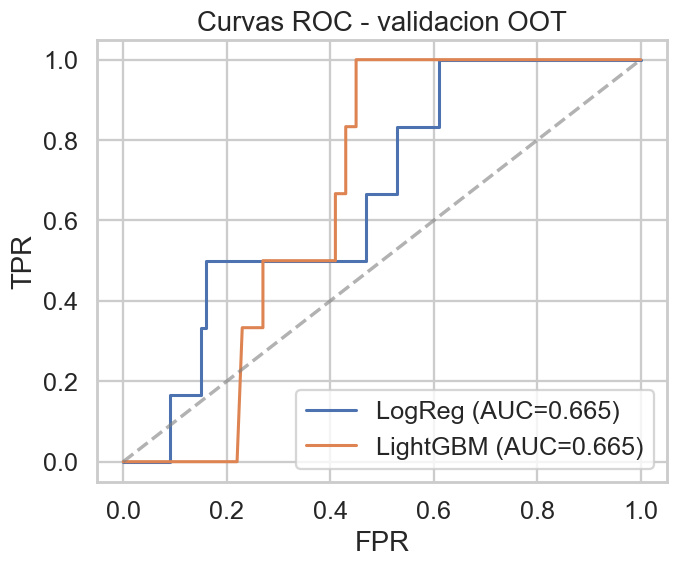

In [17]:
# Curvas ROC en OOT
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, p in [("LogReg", p_oot_lr), ("LightGBM", p_oot_gbm)]:
    fpr, tpr, _ = roc_curve(y_oot, p)
    auc = roc_auc_score(y_oot, p)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1], "--", color="grey", alpha=0.6)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Curvas ROC - validacion OOT")
ax.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/01_roc_oot.png", bbox_inches="tight"); plt.show()


**Lectura.** En OOT ambos modelos muestran capacidad discriminante similar. Como la diferencia es marginal y la **logistica permite generar una scorecard interpretable** (requisito habitual en areas de Riesgo y reguladores), se elige la **logistica como modelo final**. LightGBM se conserva como **modelo champion-challenger** para monitoreo.

In [18]:
# Coeficientes - drivers de riesgo (top en magnitud)
coef = pd.Series(logreg.coef_[0], index=X_tr_enc.columns).sort_values(key=lambda s: s.abs(), ascending=False)
top_drivers = coef.head(15).to_frame("coef")
top_drivers["direccion"] = np.where(top_drivers["coef"]>0, "+ riesgo", "- riesgo")
top_drivers


,coef,direccion
Edad,-0.709766,- riesgo
edad_grupo_46_55,0.504935,+ riesgo
GastosFamiliares,-0.472453,- riesgo
edad_grupo_56,0.426179,+ riesgo
TIPCONTRATO_T_RMINO_INDEFINIDO,-0.398845,- riesgo
TIPCONTRATO_T_RMINO_FIJO,-0.350571,- riesgo
edad_grupo_36_45,0.338767,+ riesgo
GastoArriendo,0.332260,+ riesgo
Ingresos,0.302714,+ riesgo
TIPCONTRATO_OTROS,-0.252323,- riesgo


## 8. Punto de corte - analisis costo/beneficio

El punto de corte se debe escoger con criterio de **negocio**, no solo estadistico. Asumimos un esquema simple:

- **Costo de aprobar un malo (FN si no se rechaza):** ~ 100% del valor del prestamo (write-off + provision).
- **Beneficio de aprobar un bueno:** ~ 15% (margen tipico esperado).

Con esa relacion `costo_FN / beneficio_TN ~ 6.7x`, el modelo debe rechazar agresivamente.

A continuacion calculamos, para una grilla de cortes, la tasa de aprobacion, la tasa de malos en aprobados (riesgo residual), la ganancia esperada y elegimos el corte que **maximiza ganancia esperada** sin caer por debajo de un piso minimo de aprobacion (viabilidad de negocio).

In [19]:
# Probabilidades del modelo final (Logistica) en OOT - es la muestra realista
score = p_oot_lr
y_real = y_oot.values

LOSS_BAD  = 1.00   # perdida por aprobar un malo
GAIN_GOOD = 0.15   # ganancia por aprobar un bueno

grid = np.linspace(0.05, 0.95, 91)
rows = []
for c in grid:
    aprobado = score < c
    n_apr = aprobado.sum()
    if n_apr == 0:
        continue
    n_apr_malos  = ((aprobado) & (y_real==1)).sum()
    n_apr_buenos = n_apr - n_apr_malos
    tasa_apr = n_apr / len(y_real)
    bad_rate_apr = n_apr_malos / n_apr
    ganancia = n_apr_buenos*GAIN_GOOD - n_apr_malos*LOSS_BAD
    rows.append({"corte": c, "tasa_aprob": tasa_apr,
                 "bad_rate_aprobados": bad_rate_apr,
                 "n_aprobados": n_apr, "ganancia_esperada": ganancia})

curva = pd.DataFrame(rows)

# corte optimo: maxima ganancia con piso minimo 25% de aprobacion (viabilidad de negocio)
PISO_APROBACION = 0.25
viable = curva[curva["tasa_aprob"] >= PISO_APROBACION]
corte_opt = viable.loc[viable["ganancia_esperada"].idxmax(), "corte"]
print(f"Corte optimo recomendado (piso aprobacion {PISO_APROBACION:.0%}): {corte_opt:.3f}")


Corte optimo recomendado (piso aprobacion 25%): 0.600


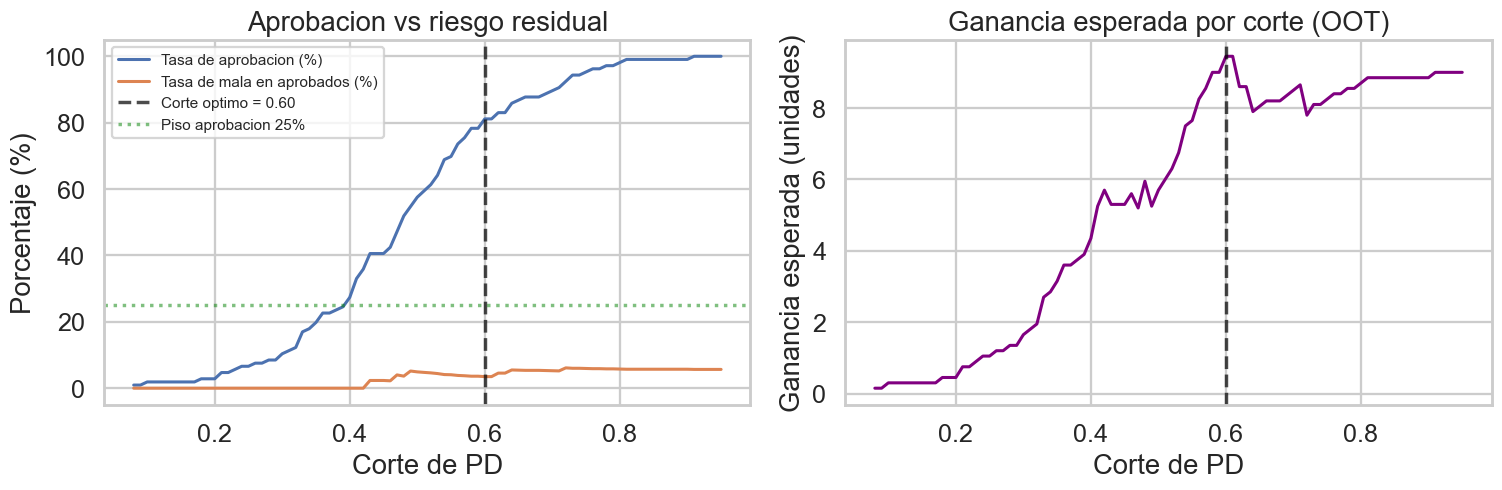

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(curva["corte"], curva["tasa_aprob"]*100, label="Tasa de aprobacion (%)", lw=2)
axes[0].plot(curva["corte"], curva["bad_rate_aprobados"]*100, label="Tasa de mala en aprobados (%)", lw=2)
axes[0].axvline(corte_opt, color="black", ls="--", alpha=0.7, label=f"Corte optimo = {corte_opt:.2f}")
axes[0].axhline(PISO_APROBACION*100, color="green", ls=":", alpha=0.5, label=f"Piso aprobacion {PISO_APROBACION:.0%}")
axes[0].set_xlabel("Corte de PD"); axes[0].set_ylabel("Porcentaje (%)")
axes[0].set_title("Aprobacion vs riesgo residual"); axes[0].legend(fontsize=10)

axes[1].plot(curva["corte"], curva["ganancia_esperada"], lw=2, color="purple")
axes[1].axvline(corte_opt, color="black", ls="--", alpha=0.7)
axes[1].set_xlabel("Corte de PD"); axes[1].set_ylabel("Ganancia esperada (unidades)")
axes[1].set_title("Ganancia esperada por corte (OOT)")

plt.tight_layout(); plt.savefig(f"{FIGS}/01_corte_optimo.png", bbox_inches="tight"); plt.show()


In [21]:
# Tabla decilica del modelo final (Logistica) sobre OOT
dec = utils.decile_table(y_oot, p_oot_lr, bins=10)
dec_show = dec.copy()
for c in ["bad_rate","%malos_acum","%buenos_acum","KS","lift"]:
    dec_show[c] = dec_show[c].round(3)
dec_show


,banda,n,malos,score_min,score_max,buenos,bad_rate,%malos_acum,%buenos_acum,KS,lift
0,1,11,1,0.704293,0.907916,10,0.091,0.167,0.10,0.067,1.606
1,2,11,2,0.596404,0.692578,9,0.182,0.500,0.19,0.310,3.212
2,3,10,0,0.551114,0.594780,10,0.000,0.500,0.29,0.210,0.000
3,4,11,0,0.511549,0.542599,11,0.000,0.500,0.40,0.100,0.000
4,5,10,1,0.477192,0.504656,9,0.100,0.667,0.49,0.177,1.767
5,6,11,1,0.429216,0.475693,10,0.091,0.833,0.59,0.243,1.606
6,7,10,1,0.404442,0.427592,9,0.100,1.000,0.68,0.320,1.767
7,8,11,0,0.350787,0.404263,11,0.000,1.000,0.79,0.210,0.000
8,9,10,0,0.301549,0.345350,10,0.000,1.000,0.89,0.110,0.000
9,10,11,0,0.076547,0.298973,11,0.000,1.000,1.00,0.000,0.000


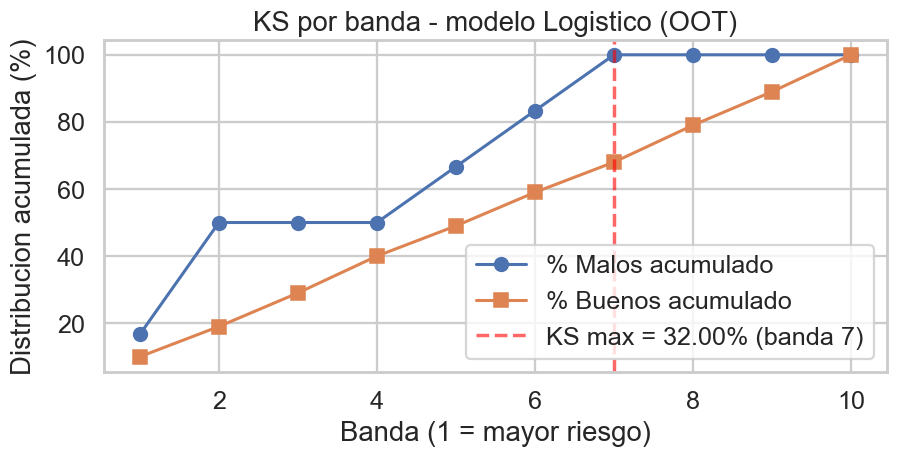

In [22]:
# Visual: KS por banda
plt.figure(figsize=(8.5, 4.5))
plt.plot(dec["banda"], dec["%malos_acum"]*100, marker="o", label="% Malos acumulado", lw=2)
plt.plot(dec["banda"], dec["%buenos_acum"]*100, marker="s", label="% Buenos acumulado", lw=2)
ks_max = dec["KS"].max()
banda_ks = dec.loc[dec["KS"].idxmax(),"banda"]
plt.axvline(banda_ks, color="red", ls="--", alpha=0.6, label=f"KS max = {ks_max:.2%} (banda {banda_ks})")
plt.xlabel("Banda (1 = mayor riesgo)"); plt.ylabel("Distribucion acumulada (%)")
plt.title("KS por banda - modelo Logistico (OOT)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{FIGS}/01_ks_oot.png", bbox_inches="tight"); plt.show()


## 9. Conclusiones ejecutivas

**Hallazgo critico.** Se detecto data leakage en `MoraMax_UltimoSemestre` (variable que coincide casi perfectamente con la definicion del target). Su exclusion es necesaria para tener metricas confiables y representativas de produccion.

**Variable objetivo.** Se eligio **Mora60** por estar mejor alineada con el concepto operativo de default y con el costo real de incumplimiento en un segmento de alto riesgo. El IV agregado de las predictoras se mantiene comparable contra ambos targets, por lo que no hay perdida material de senal.

**Modelo final.** Regresion logistica con balanceo de clases. Como la diferencia con LightGBM en OOT es marginal, se prefiere por **interpretabilidad y trazabilidad regulatoria** (estandar en Riesgo de Credito). LightGBM se conserva como challenger para monitoreo.

**Punto de corte recomendado.** Se recomienda usar el corte que **maximiza la ganancia esperada** asumiendo que perder un malo cuesta ~6.7x lo que se gana con un bueno, sujeto a un piso de aprobacion del 25% para mantener viabilidad comercial. Este corte se debe **monitorear mensualmente con PSI** y recalibrar si > 0.25.

**Drivers de riesgo identificados** (top de la logistica): variables de capacidad de pago (PORCEND, ratios sobre ingresos), comportamiento financiero previo (ExperienciaSectorFinanciero, TiempoClienteMeses) y demograficas (Edad, TipoVivienda) destacan como las mas predictivas, coherente con literatura de credit scoring.

**Limitaciones.** (1) Volumen relativamente bajo (4.3k registros) - intervalo de confianza amplio. (2) Periodo de un solo ano - no captura ciclos. (3) No se cuenta con scores de bureau ni variables transaccionales que tipicamente elevan el Gini al 0.45-0.55. (4) Recomendamos **monitoreo mensual de PSI y KS** y reentrenamiento cada 6 meses.


---

**Persistencia para uso en otros notebooks / informe**

In [23]:
# Guardar metricas y curva de corte para reusar en el informe / presentacion
os.makedirs("datos", exist_ok=True)
metrics_df.to_csv("datos/01_metricas_modelos.csv", index=False)
curva.to_csv("datos/01_curva_corte.csv", index=False)
dec.to_csv("datos/01_decilica_logreg_oot.csv", index=False)
top_drivers.to_csv("datos/01_drivers.csv")
pd.DataFrame({"corte_optimo":[corte_opt], "piso_aprobacion":[PISO_APROBACION],
              "loss_bad":[LOSS_BAD], "gain_good":[GAIN_GOOD]}).to_csv("datos/01_corte.csv", index=False)
print("Artefactos guardados en datos/")


Artefactos guardados en datos/
